# EEGDash NM000228 Exploration

This notebook probes the `eegdash` API around `NM000228` before downloading raw signal data. The raw object is lazy: touching `recording.raw` downloads and caches that recording locally.

In [16]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("eegdash") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "eegdash"])

import eegdash

print("eegdash", getattr(eegdash, "__version__", "unknown"))
print("python", sys.executable)

eegdash 0.8.2
python /home/odra/miniconda3/envs/scrabrain/bin/python


In [17]:
from pathlib import Path
from pprint import pprint

import pandas as pd

if Path.cwd().name == "eegdash" and Path.cwd().parent.name == "datasets":
    NOTEBOOK_DIR = Path.cwd()
else:
    candidate = Path.cwd() / "datasets" / "eegdash"
    NOTEBOOK_DIR = candidate if candidate.exists() else Path.cwd()

CACHE_DIR = NOTEBOOK_DIR / "data"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def as_description_dict(description):
    if description is None:
        return {}
    if hasattr(description, "to_dict"):
        return description.to_dict()
    if isinstance(description, dict):
        return description
    return {}

print("notebook dir:", NOTEBOOK_DIR.resolve())
print("cache dir:", CACHE_DIR.resolve())

notebook dir: /home/odra/GitHub/ScraBrain/datasets/eegdash
cache dir: /home/odra/GitHub/ScraBrain/datasets/eegdash/data


## Dataset-level catalogue metadata

`EEGDash` can inspect dataset metadata without loading signal files.

In [19]:
from eegdash import EEGDash
from eegdash.dataset import NM000228

client = EEGDash()
dataset_doc = client.get_dataset("nm000228")

print(type(dataset_doc))
print("top-level keys:")
pprint(sorted(dataset_doc.keys()) if dataset_doc else None)

if dataset_doc:
    fields = [
        "dataset",
        "name",
        "title",
        "source",
        "license",
        "dataset_doi",
        "modality",
        "task",
        "n_subjects",
        "n_recordings",
        "total_size",
        "bids_version",
    ]
    pprint({field: dataset_doc.get(field) for field in fields if field in dataset_doc})

<class 'dict'>
top-level keys:
['_id',
 'associated_paper_doi',
 'author_year',
 'authors',
 'bids_version',
 'canonical_name',
 'computed_title',
 'contact_info',
 'contributing_labs',
 'data_processed',
 'dataset_doi',
 'dataset_id',
 'datatypes',
 'demographics',
 'experimental_modalities',
 'external_links',
 'funding',
 'ingestion_fingerprint',
 'license',
 'n_contributing_labs',
 'name',
 'nchans_counts',
 'readme',
 'recording_modality',
 'senior_author',
 'sessions',
 'sfreq_counts',
 'size_bytes',
 'source',
 'stats_computed_at',
 'storage',
 'study_design',
 'study_domain',
 'tasks',
 'timestamps',
 'total_duration_s',
 'total_files']
{'bids_version': '1.9.0',
 'dataset_doi': 'doi:10.7554/eLife.33468',
 'license': 'CC-BY 4.0',
 'name': 'Nieuwland et al. 2018: Multi-site N400 Replication Study',
 'source': 'nemar'}


In [20]:
matches = client.search_datasets(modality="eeg", source="nemar", n_subjects_min=300, limit=20)
matches

,dataset_id,name,modality,task,n_subjects,source,license,dataset_doi
0,ds000117,"Multisubject, multimodal face processing",None,None,None,openneuro,CC0,doi:10.18112/openneuro.ds000117.v1.1.0
1,ds000246,MEG-BIDS Brainstorm data sample,None,None,None,openneuro,CC0,doi:10.18112/openneuro.ds000246.v1.0.1
2,ds000247,MEG-BIDS OMEGA RestingState_sample,None,None,None,openneuro,CC0,doi:10.18112/openneuro.ds000247.v1.0.2
3,ds000248,,None,None,None,openneuro,CC0,10.18112/openneuro.ds000248.v1.2.4
4,ds001785,Evidence accumulation relates to perceptual co...,None,None,None,openneuro,CC0,10.18112/openneuro.ds001785.v1.1.1
5,ds001787,EEG meditation study,None,None,None,openneuro,CC0,doi:10.18112/openneuro.ds001787.v1.1.1
6,ds001810,"EEG study of the attentional blink; before, du...",None,None,None,openneuro,CC0,10.18112/openneuro.ds001810.v1.1.0
7,ds001849,RS_TMSEEG_Data,None,None,None,openneuro,CC0,10.18112/openneuro.ds001849.v1.0.2
8,ds001971,Audiocue walking study,None,None,None,openneuro,Creative commons,10.18112/openneuro.ds001971.v1.1.1
9,ds002001,Rivalry_Tagging,None,None,None,openneuro,PD,10.18112/openneuro.ds002001.v1.0.0


## Recording collection

Constructing `NM000228` queries the catalogue and builds a `BaseConcatDataset` of lazy recording objects. It should not download raw data until `.raw` is accessed.

In [21]:
dataset = NM000228(cache_dir=str(CACHE_DIR), on_error="warn")

print("dataset type:", type(dataset))
print("query:", dataset.query)
print("record objects:", len(dataset.datasets))
print("metadata records:", len(dataset.records))
print("data dir:", dataset.data_dir)

dataset type: <class 'eegdash.dataset.dataset.NM000228'>
query: {'dataset': 'nm000228'}
record objects: 397
metadata records: 397
data dir: /home/odra/GitHub/ScraBrain/datasets/eegdash/data/nm000228


In [22]:
recording = dataset.datasets[0]

print("recording type:", type(recording))
print("description:")
pprint(as_description_dict(recording.description))
print("bidspath:", recording.bidspath)
print("local cache file:", recording.filecache)
print("remote URI:", recording.s3file)

record_fields = [
    "dataset",
    "bids_relpath",
    "subject",
    "session",
    "task",
    "run",
    "datatype",
    "suffix",
    "extension",
    "sampling_frequency",
    "nchans",
    "ntimes",
    "duration",
]
pprint({field: recording.record.get(field) for field in record_fields if field in recording.record})

recording type: <class 'eegdash.dataset.base.EEGDashRaw'>
description:
{'accuracy': 80.0,
 'age': None,
 'age_range': '18-35',
 'gender': None,
 'hand': 'R',
 'included_in_paper': 'True',
 'institution': 'University of Kent',
 'lab': 'kent',
 'lab_number': 5.0,
 'list': 2.0,
 'n_article_trials': 78.0,
 'n_noun_trials': 80.0,
 'native_language': 'English',
 'recording_system': 'Brain Products BrainVision BrainAmp',
 'run': None,
 'session': None,
 'sex': None,
 'subject': 'kent0034',
 'task': 'delong'}
bidspath: /home/odra/GitHub/ScraBrain/datasets/eegdash/data/nm000228/sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf
local cache file: /home/odra/GitHub/ScraBrain/datasets/eegdash/data/nm000228/sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf
remote URI: None
{'bids_relpath': 'sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf',
 'dataset': 'nm000228',
 'datatype': 'eeg',
 'extension': '.bdf',
 'nchans': 64,
 'ntimes': 1275319,
 'run': None,
 'sampling_frequency': 500.0,
 'session': Non

## Metadata table

Flatten the catalogue records to learn which fields are available for filtering and downstream labels.

In [23]:
records = pd.json_normalize(dataset.records)
print(records.shape)
records.head()

(397, 448)


,_id,data_name,_has_missing_files,bids_relpath,bidspath,ch_names,dataset,datatype,digested_at,extension,...,storage.annex_keys.sub-lond018/eeg/sub-lond018_task-delong_eeg.bdf,storage.annex_keys.sub-glas001/eeg/sub-glas001_task-delong_eeg.bdf,storage.annex_keys.sub-stir30/eeg/sub-stir30_task-delong_eeg.bdf,storage.annex_keys.sub-lond027/eeg/sub-lond027_task-delong_eeg.bdf,storage.annex_keys.sub-edin17/eeg/sub-edin17_task-delong_eeg.bdf,storage.annex_keys.sub-glas039/eeg/sub-glas039_task-delong_eeg.bdf,storage.annex_keys.sub-edin28/eeg/sub-edin28_task-delong_eeg.bdf,storage.annex_keys.sub-lond020/eeg/sub-lond020_task-delong_eeg.bdf,storage.annex_keys.sub-stir37/eeg/sub-stir37_task-delong_eeg.bdf,storage.annex_keys.sub-glas006/eeg/sub-glas006_task-delong_eeg.bdf
0,69de3cb1897a7725c67010c3,nm000228_sub-kent0034_task-delong_eeg.bdf,False,sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf,nm000228/sub-kent0034/eeg/sub-kent0034_task-de...,"[Fp1, Fp2, AF7, AF3, AF4, AF8, F7, F5, F3, F1,...",nm000228,eeg,2026-04-30T14:09:13.601177+00:00,.bdf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,69de3cb1897a7725c67010c4,nm000228_sub-york8_task-delong_eeg.bdf,False,sub-york8/eeg/sub-york8_task-delong_eeg.bdf,nm000228/sub-york8/eeg/sub-york8_task-delong_e...,"[Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, ...",nm000228,eeg,2026-04-30T14:09:13.601177+00:00,.bdf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,69de3cb1897a7725c67010c5,nm000228_sub-bris34_task-delong_eeg.bdf,False,sub-bris34/eeg/sub-bris34_task-delong_eeg.bdf,nm000228/sub-bris34/eeg/sub-bris34_task-delong...,"[Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, ...",nm000228,eeg,2026-04-30T14:09:13.601177+00:00,.bdf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,69de3cb1897a7725c67010c6,nm000228_sub-bris34_task-control_eeg.bdf,False,sub-bris34/eeg/sub-bris34_task-control_eeg.bdf,nm000228/sub-bris34/eeg/sub-bris34_task-contro...,"[Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, ...",nm000228,eeg,2026-04-30T14:09:13.601177+00:00,.bdf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,69de3cb1897a7725c67010c7,nm000228_sub-kent0033_task-delong_eeg.bdf,False,sub-kent0033/eeg/sub-kent0033_task-delong_eeg.bdf,nm000228/sub-kent0033/eeg/sub-kent0033_task-de...,"[Fp1, Fp2, AF7, AF3, AF4, AF8, F7, F5, F3, F1,...",nm000228,eeg,2026-04-30T14:09:13.601177+00:00,.bdf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
interesting = [
    "subject",
    "session",
    "task",
    "run",
    "datatype",
    "suffix",
    "extension",
    "sampling_frequency",
    "nchans",
    "duration",
    "bids_relpath",
    "storage.backend",
    "storage.base",
    "storage.raw_key",
]
available = [col for col in interesting if col in records.columns]
records[available].head(10)

,subject,session,task,run,datatype,suffix,extension,sampling_frequency,nchans,bids_relpath,storage.backend,storage.base,storage.raw_key
0,kent0034,None,delong,None,eeg,eeg,.bdf,500.0,64,sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf
1,york8,None,delong,None,eeg,eeg,.bdf,500.0,66,sub-york8/eeg/sub-york8_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-york8/eeg/sub-york8_task-delong_eeg.bdf
2,bris34,None,delong,None,eeg,eeg,.bdf,1000.0,32,sub-bris34/eeg/sub-bris34_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-bris34/eeg/sub-bris34_task-delong_eeg.bdf
3,bris34,None,control,None,eeg,eeg,.bdf,1000.0,32,sub-bris34/eeg/sub-bris34_task-control_eeg.bdf,nemar,s3://nemar/nm000228,sub-bris34/eeg/sub-bris34_task-control_eeg.bdf
4,kent0033,None,delong,None,eeg,eeg,.bdf,500.0,64,sub-kent0033/eeg/sub-kent0033_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-kent0033/eeg/sub-kent0033_task-delong_eeg.bdf
5,bris33,None,delong,None,eeg,eeg,.bdf,1000.0,32,sub-bris33/eeg/sub-bris33_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-bris33/eeg/sub-bris33_task-delong_eeg.bdf
6,bris33,None,control,None,eeg,eeg,.bdf,1000.0,32,sub-bris33/eeg/sub-bris33_task-control_eeg.bdf,nemar,s3://nemar/nm000228,sub-bris33/eeg/sub-bris33_task-control_eeg.bdf
7,kent0005,None,delong,None,eeg,eeg,.bdf,500.0,64,sub-kent0005/eeg/sub-kent0005_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-kent0005/eeg/sub-kent0005_task-delong_eeg.bdf
8,stir4,None,delong,None,eeg,eeg,.bdf,250.0,66,sub-stir4/eeg/sub-stir4_task-delong_eeg.bdf,nemar,s3://nemar/nm000228,sub-stir4/eeg/sub-stir4_task-delong_eeg.bdf
9,bris05,None,control,None,eeg,eeg,.bdf,1000.0,32,sub-bris05/eeg/sub-bris05_task-control_eeg.bdf,nemar,s3://nemar/nm000228,sub-bris05/eeg/sub-bris05_task-control_eeg.bdf


In [25]:
for col in ["task", "session", "extension", "sampling_frequency", "nchans", "storage.backend"]:
    if col in records.columns:
        print(f"\n{col}")
        print(records[col].value_counts(dropna=False).head(20))

if "subject" in records.columns:
    print("\nsubjects:", records["subject"].nunique())


task
task
delong     356
control     41
Name: count, dtype: int64

session
session
None    397
Name: count, dtype: int64

extension
extension
.bdf    397
Name: count, dtype: int64

sampling_frequency
sampling_frequency
500.0     122
512.0     116
1000.0     78
2048.0     41
250.0      40
Name: count, dtype: int64

nchans
nchans
66     81
32     78
73     77
65     43
41     40
64     38
144    37
138     3
Name: count, dtype: int64

storage.backend
storage.backend
nemar    397
Name: count, dtype: int64

subjects: 356


## Iteration and filtering

Each item in `dataset.datasets` is one lazy recording. The dataset wrapper also supports MongoDB-style query filters.

In [26]:
for idx, rec in enumerate(dataset.datasets[:5]):
    desc = as_description_dict(rec.description)
    print(
        idx,
        "subject=", desc.get("subject") or rec.record.get("subject"),
        "task=", desc.get("task") or rec.record.get("task"),
        "sfreq=", rec.record.get("sampling_frequency"),
        "nchans=", rec.record.get("nchans"),
        "path=", rec.record.get("bids_relpath"),
    )

0 subject= kent0034 task= delong sfreq= 500.0 nchans= 64 path= sub-kent0034/eeg/sub-kent0034_task-delong_eeg.bdf
1 subject= york8 task= delong sfreq= 500.0 nchans= 66 path= sub-york8/eeg/sub-york8_task-delong_eeg.bdf
2 subject= bris34 task= delong sfreq= 1000.0 nchans= 32 path= sub-bris34/eeg/sub-bris34_task-delong_eeg.bdf
3 subject= bris34 task= control sfreq= 1000.0 nchans= 32 path= sub-bris34/eeg/sub-bris34_task-control_eeg.bdf
4 subject= kent0033 task= delong sfreq= 500.0 nchans= 64 path= sub-kent0033/eeg/sub-kent0033_task-delong_eeg.bdf


In [27]:
subjects = records["subject"].dropna().astype(str).drop_duplicates().head(2).tolist()
print("example subjects:", subjects)

if subjects:
    small = NM000228(
        cache_dir=str(CACHE_DIR),
        query={"subject": {"$in": subjects}},
        on_error="warn",
    )
    print("filtered recordings:", len(small.datasets))
    for rec in small.datasets[:10]:
        print(as_description_dict(rec.description))

example subjects: ['kent0034', 'york8']
filtered recordings: 2
{'subject': 'kent0034', 'task': 'delong', 'lab': 'kent', 'lab_number': 5.0, 'institution': 'University of Kent', 'list': 2.0, 'accuracy': 80.0, 'n_article_trials': 78.0, 'n_noun_trials': 80.0, 'included_in_paper': 'True', 'hand': 'R', 'age_range': '18-35', 'native_language': 'English', 'recording_system': 'Brain Products BrainVision BrainAmp', 'session': None, 'run': None, 'age': None, 'gender': None, 'sex': None}
{'subject': 'york8', 'task': 'delong', 'lab': 'york', 'lab_number': 9.0, 'institution': 'University of York', 'list': 2.0, 'accuracy': 100.0, 'n_article_trials': 78.0, 'n_noun_trials': 78.0, 'included_in_paper': 'True', 'hand': 'R', 'age_range': '18-35', 'native_language': 'English', 'recording_system': 'Brain Products BrainVision actiCHamp', 'session': None, 'run': None, 'age': None, 'gender': None, 'sex': None}


## Optional raw download

Set `LOAD_RAW = True` to download and inspect the first recording as an MNE `Raw` object. Leave it off for metadata-only exploration.

In [29]:
LOAD_RAW = True

if LOAD_RAW:
    import mne

    raw = dataset.datasets[0].raw
    if raw is None:
        print("Raw load returned None. Check warnings above for data integrity or access errors.")
    else:
        print(raw.info)
        print("channels:", len(raw.ch_names), raw.ch_names[:20])
        print("sfreq:", raw.info["sfreq"])
        print("duration seconds:", raw.times[-1])
        print("annotations:", len(raw.annotations))
        print(raw.annotations[:10])

        try:
            events, event_id = mne.events_from_annotations(raw, verbose=False)
            print("events shape:", events.shape)
            pprint(event_id)
        except Exception as exc:
            print("Could not derive events from annotations:", repr(exc))
else:
    print("Raw download skipped. Change LOAD_RAW to True when ready to cache one recording.")

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, AF7, AF3, AF4, AF8, F7, F5, F3, F1, Fz, F2, F4, F6, ...
 chs: 62 EEG, 2 EOG
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 100.0 Hz
 meas_date: 2016-06-14 16:47:40 UTC
 nchan: 64
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: sub-kent0034, hand: 1, sex: 0>
>
channels: 64 ['Fp1', 'Fp2', 'AF7', 'AF3', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FC2']
sfreq: 500.0
duration seconds: 2550.998
annotations: 2916
<Annotations | 10 segments: filler_word/255 (9), question (1)>
events shape: (2915, 3)
{np.str_('a_expected'): 1,
 np.str_('a_unexpected'): 2,
 np.str_('an_expected'): 3,
 np.str_('an_unexpected'): 4,
 np.str_('cloze_marker/100'): 5,
 np.str_('cloze_marker/11'): 6,
 np.str_('cloze_marker/13'): 7,
 np.str_('cloze_marker/14'): 8,
 np.str_('cloze_marker/16'): 9,
 np.str_('cloze_marker/17'): 10,
 np.str_('cloze_marker/18'): 11,
 np.str

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Setting 180 of 1275500 (0.01%) samples to NaN, retaining 1275320 (99.99%) samples.
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.


/tmp/ipykernel_26353/3074222311.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=80)
/home/odra/miniconda3/envs/scrabrain/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


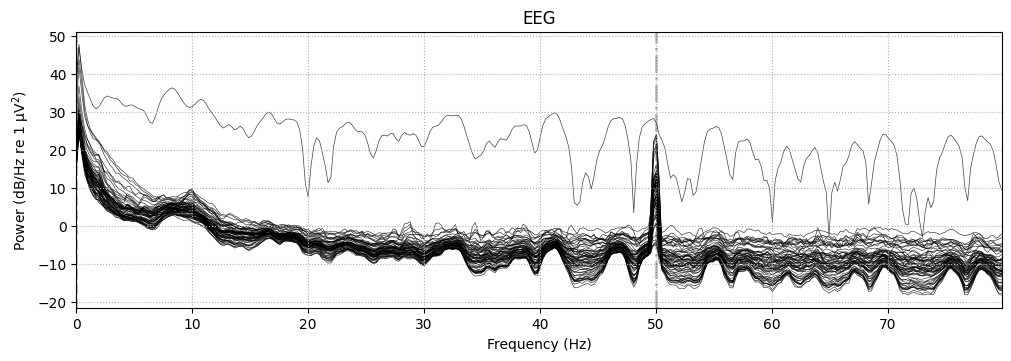

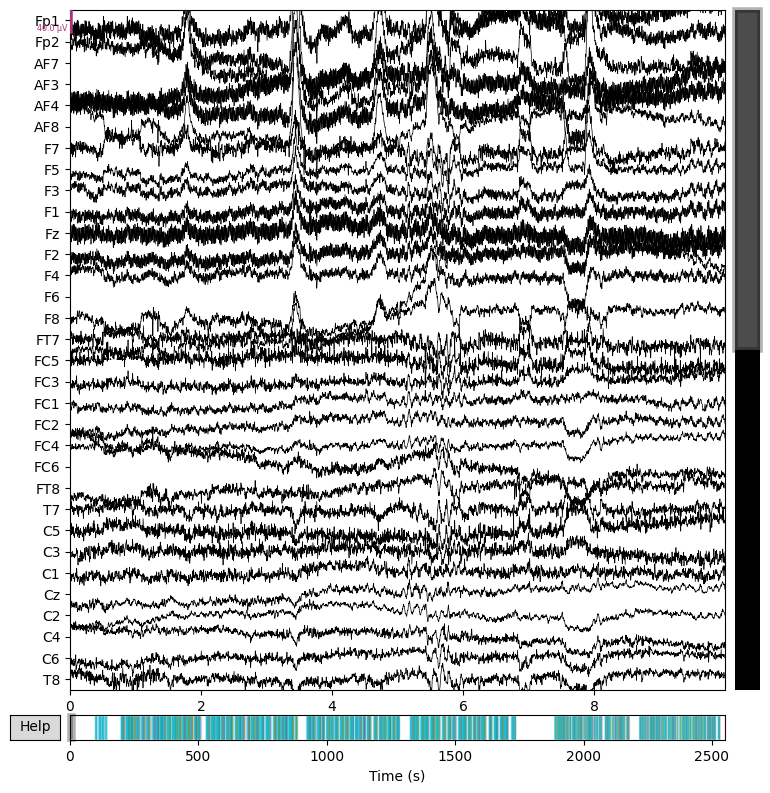

In [30]:
if LOAD_RAW and "raw" in globals() and raw is not None:
    raw.plot_psd(fmax=80)
    raw.plot(duration=10, n_channels=min(32, len(raw.ch_names)))